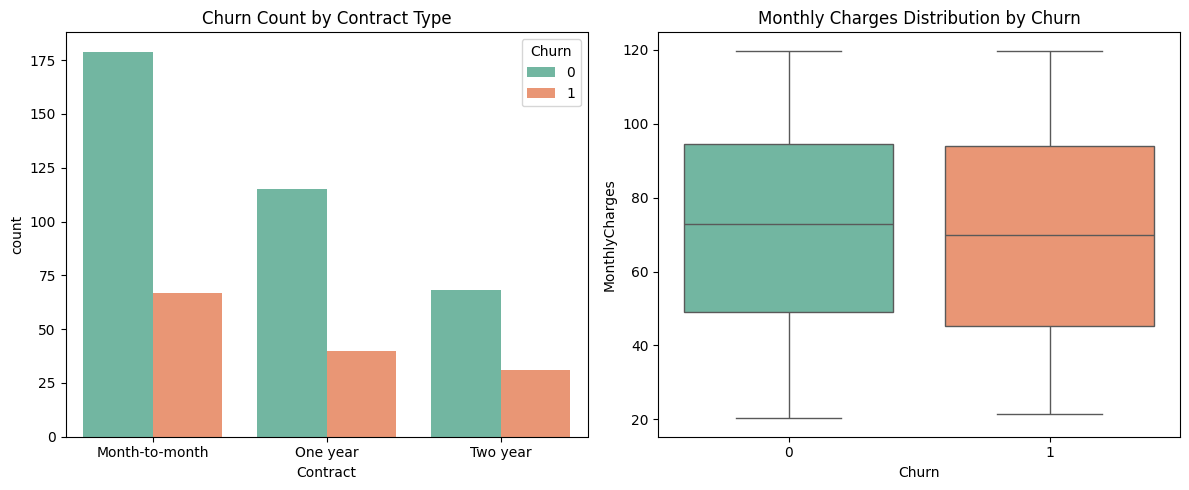

,Contract,Churn
0,Month-to-month,0.272358
1,One year,0.258065
2,Two year,0.313131


데이터 크기: (5000, 21)

컬럼 목록:
 ['state', 'account_length', 'area_code', 'phone_number', 'international_plan', 'voice_mail_plan', 'number_vmail_messages', 'total_day_minutes', 'total_day_calls', 'total_day_charge', 'total_eve_minutes', 'total_eve_calls', 'total_eve_charge', 'total_night_minutes', 'total_night_calls', 'total_night_charge', 'total_intl_minutes', 'total_intl_calls', 'total_intl_charge', 'number_customer_service_calls', 'class']

결측치 개수:
 state                            0
account_length                   0
area_code                        0
phone_number                     0
international_plan               0
voice_mail_plan                  0
number_vmail_messages            0
total_day_minutes                0
total_day_calls                  0
total_day_charge                 0
total_eve_minutes                0
total_eve_calls                  0
total_eve_charge                 0
total_night_minutes              0
total_night_calls                0
total_night_charge     

,state,account_length,area_code,phone_number,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,...,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,class
0,16,128,415,2845,0,1,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,35,107,415,2301,0,1,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,31,137,415,1616,0,0,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,35,84,408,2510,1,0,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,36,75,415,155,1,0,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n_samples = 500

data = {
    'Tenure': np.random.randint(1, 72, n_samples),
    'MonthlyCharges': np.random.uniform(20.0, 120.0, n_samples),
    'Contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], n_samples, p=[0.5, 0.3, 0.2]),
    'Churn': np.random.choice([0, 1], n_samples, p=[0.7, 0.3])
}
df = pd.DataFrame(data)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Churn Count by Contract Type')

sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1], hue='Churn', legend=False, palette='Set2')
axes[1].set_title('Monthly Charges Distribution by Churn')

plt.tight_layout()
plt.show()

churn_rate = df.groupby('Contract')['Churn'].mean().reset_index()
display(churn_rate)

from sklearn.datasets import fetch_openml

churn_real = fetch_openml(name='churn', version=1, as_frame=True)
df_real = churn_real.frame.copy()

print("데이터 크기:", df_real.shape)
print("\n컬럼 목록:\n", df_real.columns.tolist())
print("\n결측치 개수:\n", df_real.isnull().sum())
print("\n타겟 변수(class) 분포:\n", df_real['class'].value_counts())

df_real.head()

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix

numeric_cols = df_real.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df_real[numeric_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = [(row, col, upper.loc[row, col]) for col in upper.columns for row in upper.index if upper.loc[row, col] > 0.95]
print("다중공선성 의심 변수쌍 (상관계수 0.95 초과)")
for row, col, val in high_corr_pairs:
    print(f"  {row} - {col}: {val:.4f}")

drop_cols = ['total_day_charge', 'total_eve_charge', 'total_night_charge', 'total_intl_charge', 'phone_number', 'state']
df_clean = df_real.drop(columns=drop_cols)

le_intl = LabelEncoder()
le_vmail = LabelEncoder()
df_clean['international_plan'] = le_intl.fit_transform(df_clean['international_plan'])
df_clean['voice_mail_plan'] = le_vmail.fit_transform(df_clean['voice_mail_plan'])

y = df_clean['class'].astype(int)
X = df_clean.drop(columns=['class'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])
pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)

print("\n예측 모델 성능")
print(f"Precision: {precision_score(y_test, preds):.4f}")
print(f"Recall: {recall_score(y_test, preds):.4f}")
print(f"F1 Score: {f1_score(y_test, preds):.4f}")
print("\nConfusion Matrix")
print(confusion_matrix(y_test, preds))

다중공선성 의심 변수쌍 (상관계수 0.95 초과)
  total_day_minutes - total_day_charge: 1.0000
  total_eve_minutes - total_eve_charge: 1.0000
  total_night_minutes - total_night_charge: 1.0000
  total_intl_minutes - total_intl_charge: 1.0000

예측 모델 성능
Precision: 0.3607
Recall: 0.7163
F1 Score: 0.4798

Confusion Matrix
[[680 179]
 [ 40 101]]
